# Feature-Selection



**Retrival the important features, selecting an important features is very important step before going to ML**

. Droping the constant fetaures ( Regression and classification)

. Information gain (Classification)

· p-value (Regression)

· VIF (Regression)

. Forward selection and backward selection (Regression and classification)

. Correlation with target column ( RegressionIand classification)

# Feature selection method

1. Varience threshold method:
   - based on varience we can decide data is constant or varing
   - Data is not varing not much means, Data has some Value
   - For example we have seen in load_ data set, loan tern : 360
   - Python by default will use varience =0,it will drop those features which are having varience =0
   - varience threshold is hyper Paramerter , we can keep threshold as any value
   - based internal tean discution
   - we will drop those feature which are having <= threshold value
2. P-value :
   - H0: There is is no relation to x and y
   - H1: There is relation X and Y
   -  p<0.05
       -  Reject the Null hypothesis: **Which means do not include the variable**
   -  p>0.05
       - Not reject the Null Hypothesis :  **which means include the variable**
3. Mutual info Classify:
   - KNN and entropy
   - it will give the relation between input and output will pick which are having more relation
   - input vs Output
     - A. Entropy
     - B. KNN
     - C. R-squre: explainability about based on x
4. Forword selecction and backword selection
   
   **Forward selection method**

     - Start with empty set of features

     - Iterate throuh each feature and select the one feature that improves model performance

     - Continue adding fetaures one by one till we meet our creteria

    **Backward selection mehod**

     - Start with full set of features

     - Iterate through each feature by removing the feature which is having less impact on the model
  
     - Continue the process, till your performance is stable

- Both Forward selection and Bcakward selection methods are complex in nature

- More time taken, will avoid in general

5. Variance inflation factor(VIF):

    - VIF will give the analysis of multicollinearity

    - In VIF will find the R-Square value of each input feature wrt to other input fetaure

    - Will keep one fetaure as input and other fetaure are consider as output in Regression equation
  
    - this will keep iterate through all feature
  
    - Every feature behave as input as well as output

    - As we know every regression line give Rsqurae value from that value will fine VIF

    - will drop the feature which are having VIF>5 or VIF > 10 based on iternal team discussion
  


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd
dict1={'A':[100,200,300,400],
'B':[1,2,3,4],
'C':[10,20,30,40],
'D':[10,10,10,10]
      }
df=pd.DataFrame(dict1)

In [3]:
df

,A,B,C,D
0,100,1,10,10
1,200,2,20,10
2,300,3,30,10
3,400,4,40,10


In [4]:
import sklearn

In [5]:
from sklearn. feature_selection import VarianceThreshold
vt=VarianceThreshold(threshold=0)
# Threshold variance value
# we want to drop the feaure based on threshold
# we are finding the variance so only fit
# transform is not required
vt.fit(df)


,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0


NameError: name 'dis' is not defined

In [ ]:
# vt.feature_names_in_
# vt.get_feature_names_out()
# vt.get_params()
# vt.get_support()
# vt.n_features_in_
# vt.threshold
# vt.variances_

In [7]:
df=pd.read_csv(r"D:\Data-Science\Feature engineering\class\winequality_red.csv")

In [8]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [9]:
X=df.drop('quality', axis=1)
y=df['quality']

In [10]:
from sklearn.feature_selection import mutual_info_classif
MI=mutual_info_classif(X,y)

In [11]:
MI

array([0.06228649, 0.10727332, 0.05389464, 0.01690037, 0.03497923,
       0.03219428, 0.05591364, 0.07756985, 0.01651518, 0.08846132,
       0.18537484])

In [16]:
d = pd.DataFrame(MI, index=X.columns, columns=['MI'])

In [24]:
final_cols=d.sort_values(by='MI').index[:5]

In [26]:
new_df=X[final_cols]

In [28]:
new_df['quality']=y

C:\Users\rohit\AppData\Local\Temp\ipykernel_11112\1305278086.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['quality']=y


In [29]:
new_df

,pH,residual sugar,free sulfur dioxide,chlorides,citric acid,quality
0,3.51,1.9,11.0,0.076,0.00,5
1,3.20,2.6,25.0,0.098,0.00,5
2,3.26,2.3,15.0,0.092,0.04,5
3,3.16,1.9,17.0,0.075,0.56,6
4,3.51,1.9,11.0,0.076,0.00,5
...,...,...,...,...,...,...
1594,3.45,2.0,32.0,0.090,0.08,5
1595,3.52,2.2,39.0,0.062,0.10,6
1596,3.42,2.3,29.0,0.076,0.13,6
1597,3.57,2.0,32.0,0.075,0.12,5


In [31]:
#Sepearte input and target features
X=df.drop('quality',axis=1)
y=df['quality' ]

top_5=SelectKBest(mutual_info_classif,k=5)
val=top_5.fit(X,y)


NameError: name 'SelectKBest' is not defined

In [2]:
from sklearn. datasets import fetch_california_housing
df=fetch_california_housing(as_frame=True).frame

In [3]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

# Correlation

- i will see which column are very close
- either negative or positive way
- Variance Inflation Factor(VIF )
- -Feature selection

# Before feature selection

In [5]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

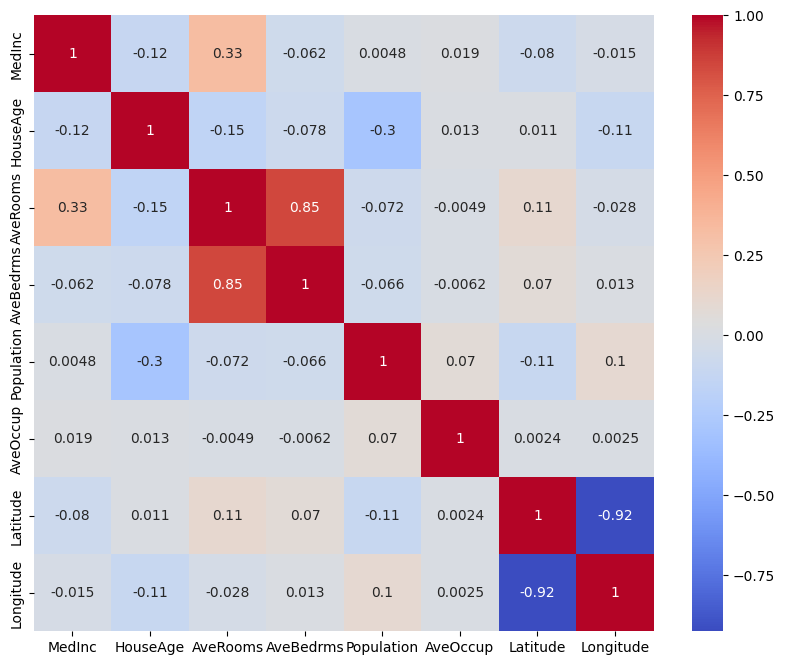

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.show()

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                  for i in range(X.shape[1])]
print(vif_data)

      Feature         VIF
0      MedInc   11.511140
1    HouseAge    7.195917
2    AveRooms   45.993601
3   AveBedrms   43.590314
4  Population    2.935745
5    AveOccup    1.095243
6    Latitude  559.874071
7   Longitude  633.711654


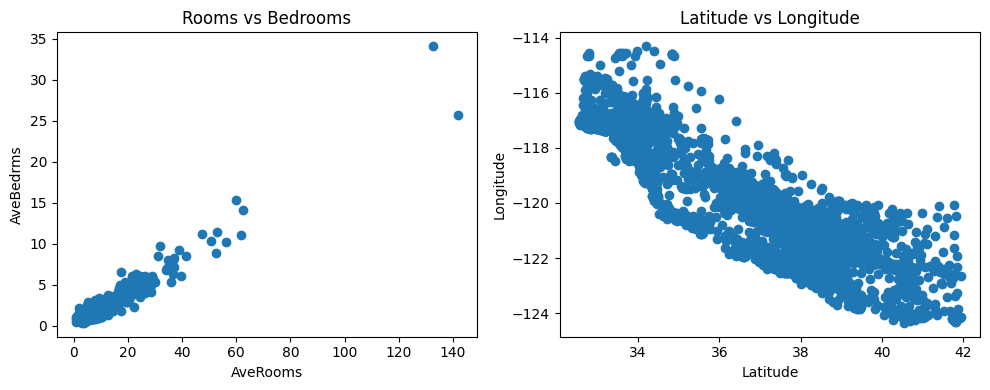

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
# First plot
plt.subplot(1,2,1)
plt.scatter(X['AveRooms'], X['AveBedrms'])
plt.xlabel('AveRooms')
plt.ylabel('AveBedrms')
plt.title('Rooms vs Bedrooms')

# Second plot
plt.subplot(1,2,2)
plt.scatter(X['Latitude'], X['Longitude'])
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.title('Latitude vs Longitude')

plt.tight_layout()
plt.show()

In [19]:
# We need to compare with VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
variance_inflation_factor(exog, exog_idx)

NameError: name 'exog' is not defined

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
X = df.drop('MedHouseVal', axis=1)  # drop target
vif_list = []
for i in range(len(X.columns)):
    vif_list.append(variance_inflation_factor(X.values, i))  # ← properly indented
vif_data = pd.DataFrame(vif_list, index=X.columns, columns=['VIF'])
print(vif_data)

                   VIF
MedInc       11.511140
HouseAge      7.195917
AveRooms     45.993601
AveBedrms    43.590314
Population    2.935745
AveOccup      1.095243
Latitude    559.874071
Longitude   633.711654


# After feature selection

- We will perform the same operation after scalling
- perform standard scaler only on input value
- then perform Vif Again

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [25]:
import pandas as pd

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [26]:
X_scaled

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818
...,...,...,...,...,...,...,...,...
20635,-1.216128,-0.289187,-0.155023,0.077354,-0.512592,-0.049110,1.801647,-0.758826
20636,-0.691593,-0.845393,0.276881,0.462365,-0.944405,0.005021,1.806329,-0.818722
20637,-1.142593,-0.924851,-0.090318,0.049414,-0.369537,-0.071735,1.778237,-0.823713
20638,-1.054583,-0.845393,-0.040211,0.158778,-0.604429,-0.091225,1.778237,-0.873626


In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_list = []
for i in range(len(X_scaled.columns)):
    vif_list.append(variance_inflation_factor(X_scaled.values, i))
vif_data = pd.DataFrame(vif_list, index=X_scaled.columns, columns=['VIF'])
print(vif_data)

                 VIF
MedInc      2.501295
HouseAge    1.241254
AveRooms    8.342786
AveBedrms   6.994995
Population  1.138125
AveOccup    1.008324
Latitude    9.297624
Longitude   8.962263


In [29]:
final_cols=['MedInc','HouseAge','AveBedrms','Population','AveOccup','Longitude']
final_df=X.loc[:,final_cols]

In [30]:
final_df.to_csv('final_california_data.csv',index=False)